<a href="https://colab.research.google.com/github/Abhi712-ui/Plant-Project/blob/main/02_data_pipeline_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [2]:
import os

#Create the training directory path
train_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

#Create the validation directory path
valid_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "valid"
)

print("Train dir exists:", os.path.isdir(train_dir))
print("Valid dir exists:", os.path.isdir(valid_dir))

Train dir exists: True
Valid dir exists: True


In [3]:
from torchvision import transforms

#use standard ImageNet values for mean and standard deviation
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
#chains multiple image transformations together
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

In [4]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transform)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Number of classes:", len(train_dataset.classes))

Training images: 70295
Validation images: 17572
Number of classes: 38


In [5]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Training batches: 2197
Validation batches: 550


In [6]:
images, labels = next(iter(train_loader))

print("Batch of images shape:", images.shape)
print("Batch of labels shape:", labels.shape)
print("Label values in this batch:", labels[:8].tolist())

Batch of images shape: torch.Size([32, 3, 224, 224])
Batch of labels shape: torch.Size([32])
Label values in this batch: [33, 19, 26, 8, 24, 37, 19, 31]


In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
import torch
import torch.nn as nn
from torchvision import models

#use resnet18 for transfer learning
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print("Original final layer:", model.fc)

num_classes = len(train_dataset.classes)
#apply a linear transformation with out features = num_classes
#model.fc is the final, fully connected layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
print("New final layer:", model.fc)

model = model.to(device)

Original final layer: Linear(in_features=512, out_features=1000, bias=True)
New final layer: Linear(in_features=512, out_features=38, bias=True)


In [9]:
#define the loss function and the optimizer

#criterion - measure how wrong the model's predictions were
criterion = nn.CrossEntropyLoss()

#optimizer - adjust the model's weights to reduce loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
#define training loop

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad() #clear the previous gradient values
        outputs = model(images) #run the model on the images
        loss = criterion(outputs, labels) #calculate loss based off the labels and the model's guesses
        loss.backward() #backward pass: compute the gradients
        optimizer.step() #update the weights

        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  batch {batch_idx}/{len(loader)}  loss {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [11]:
#Create the evaluation loop

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [12]:
num_epochs = 2
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc = evaluate(
        model,
        valid_loader,
        criterion,
        device
    )

    print(f"  train loss {train_loss:.4f}  train acc {train_acc:.4f}")
    print(f"  valid loss {valid_loss:.4f}  valid acc {valid_acc:.4f}")




Epoch 1/2
  batch 0/2197  loss 3.9662
  batch 100/2197  loss 0.5642
  batch 200/2197  loss 0.4557
  batch 300/2197  loss 0.5452
  batch 400/2197  loss 0.1797
  batch 500/2197  loss 0.3257
  batch 600/2197  loss 0.1779
  batch 700/2197  loss 0.2239
  batch 800/2197  loss 0.4088
  batch 900/2197  loss 0.0586
  batch 1000/2197  loss 0.1239
  batch 1100/2197  loss 0.1060
  batch 1200/2197  loss 0.3620
  batch 1300/2197  loss 0.2103
  batch 1400/2197  loss 0.1250
  batch 1500/2197  loss 0.1907
  batch 1600/2197  loss 0.3340
  batch 1700/2197  loss 0.0707
  batch 1800/2197  loss 0.0801
  batch 1900/2197  loss 0.1767
  batch 2000/2197  loss 0.0670
  batch 2100/2197  loss 0.0290
  train loss 0.2516  train acc 0.9215
  valid loss 0.3243  valid acc 0.9062

Epoch 2/2
  batch 0/2197  loss 0.1317
  batch 100/2197  loss 0.3590
  batch 200/2197  loss 0.0984
  batch 300/2197  loss 0.0761
  batch 400/2197  loss 0.1139
  batch 500/2197  loss 0.2020
  batch 600/2197  loss 0.0071
  batch 700/2197  loss 0

In [13]:
from google.colab import drive
import os

drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/plant-project"
os.makedirs(save_dir, exist_ok=True)

torch.save(
    model.state_dict(),
    os.path.join(save_dir, "resnet18_plant_disease.pth")
)

print("Saved to", save_dir)

Mounted at /content/drive
Saved to /content/drive/MyDrive/plant-project


In [16]:
import json
import os
from google.colab import drive

drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/plant-project"
os.makedirs(save_dir, exist_ok=True)

class_names = train_dataset.classes

json_path = os.path.join(save_dir, "class_names.json")
with open(json_path, "w") as f:
    json.dump(class_names, f)

print("Saved", len(class_names), "class names to", json_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 38 class names to /content/drive/MyDrive/plant-project/class_names.json


In [17]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    normalize
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=train_transform)

In [18]:
best_valid_acc = 0.0

for epoch in range(3):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    valid_loss, valid_acc = evaluate(
        model,
        valid_loader,
        criterion,
        device
    )
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  saved new best ({valid_acc:.4f})")

  batch 0/2197  loss 0.0204
  batch 100/2197  loss 0.1132
  batch 200/2197  loss 0.1335
  batch 300/2197  loss 0.0735
  batch 400/2197  loss 0.2677
  batch 500/2197  loss 0.0156
  batch 600/2197  loss 0.3200
  batch 700/2197  loss 0.0202
  batch 800/2197  loss 0.2509
  batch 900/2197  loss 0.0756
  batch 1000/2197  loss 0.0636
  batch 1100/2197  loss 0.1126
  batch 1200/2197  loss 0.0157
  batch 1300/2197  loss 0.0909
  batch 1400/2197  loss 0.0477
  batch 1500/2197  loss 0.0526
  batch 1600/2197  loss 0.0134
  batch 1700/2197  loss 0.2224
  batch 1800/2197  loss 0.0771
  batch 1900/2197  loss 0.0054
  batch 2000/2197  loss 0.2199
  batch 2100/2197  loss 0.0815
  saved new best (0.9737)
  batch 0/2197  loss 0.0313
  batch 100/2197  loss 0.0150
  batch 200/2197  loss 0.1337
  batch 300/2197  loss 0.0123
  batch 400/2197  loss 0.0368
  batch 500/2197  loss 0.0265
  batch 600/2197  loss 0.0031
  batch 700/2197  loss 0.0031
  batch 800/2197  loss 0.0003
  batch 900/2197  loss 0.3489
  batc

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(
    "best_model.pth",
    "/content/drive/MyDrive/plant-project/best_model.pth"
)
print("Copied to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive.


In [22]:
#load the best weights

save_dir = "/content/drive/MyDrive/plant-project"

model.load_state_dict(
    torch.load(
        os.path.join(save_dir, "best_model.pth")
    )
)

model = model.to(device)
model.eval()
print("Best weights loaded")

Best weights loaded


In [23]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(f"Collected {len(all_preds)} predictions")

Collected 17572 predictions


In [24]:
from sklearn.metrics import classification_report, accuracy_score

class_names = train_dataset.classes
print(f"Overall accuracy: {accuracy_score(all_labels, all_preds):.4f}\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=3
    )
)

Overall accuracy: 0.9825

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.994     0.994     0.994       504
                                 Apple___Black_rot      0.998     0.972     0.985       497
                          Apple___Cedar_apple_rust      0.986     0.980     0.983       440
                                   Apple___healthy      0.990     0.994     0.992       502
                               Blueberry___healthy      0.996     0.987     0.991       454
          Cherry_(including_sour)___Powdery_mildew      1.000     0.995     0.998       421
                 Cherry_(including_sour)___healthy      1.000     0.998     0.999       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.984     0.883     0.931       410
                       Corn_(maize)___Common_rust_      0.970     1.000     0.985       477
               Corn_(maize)___Northern_Leaf_Blight   

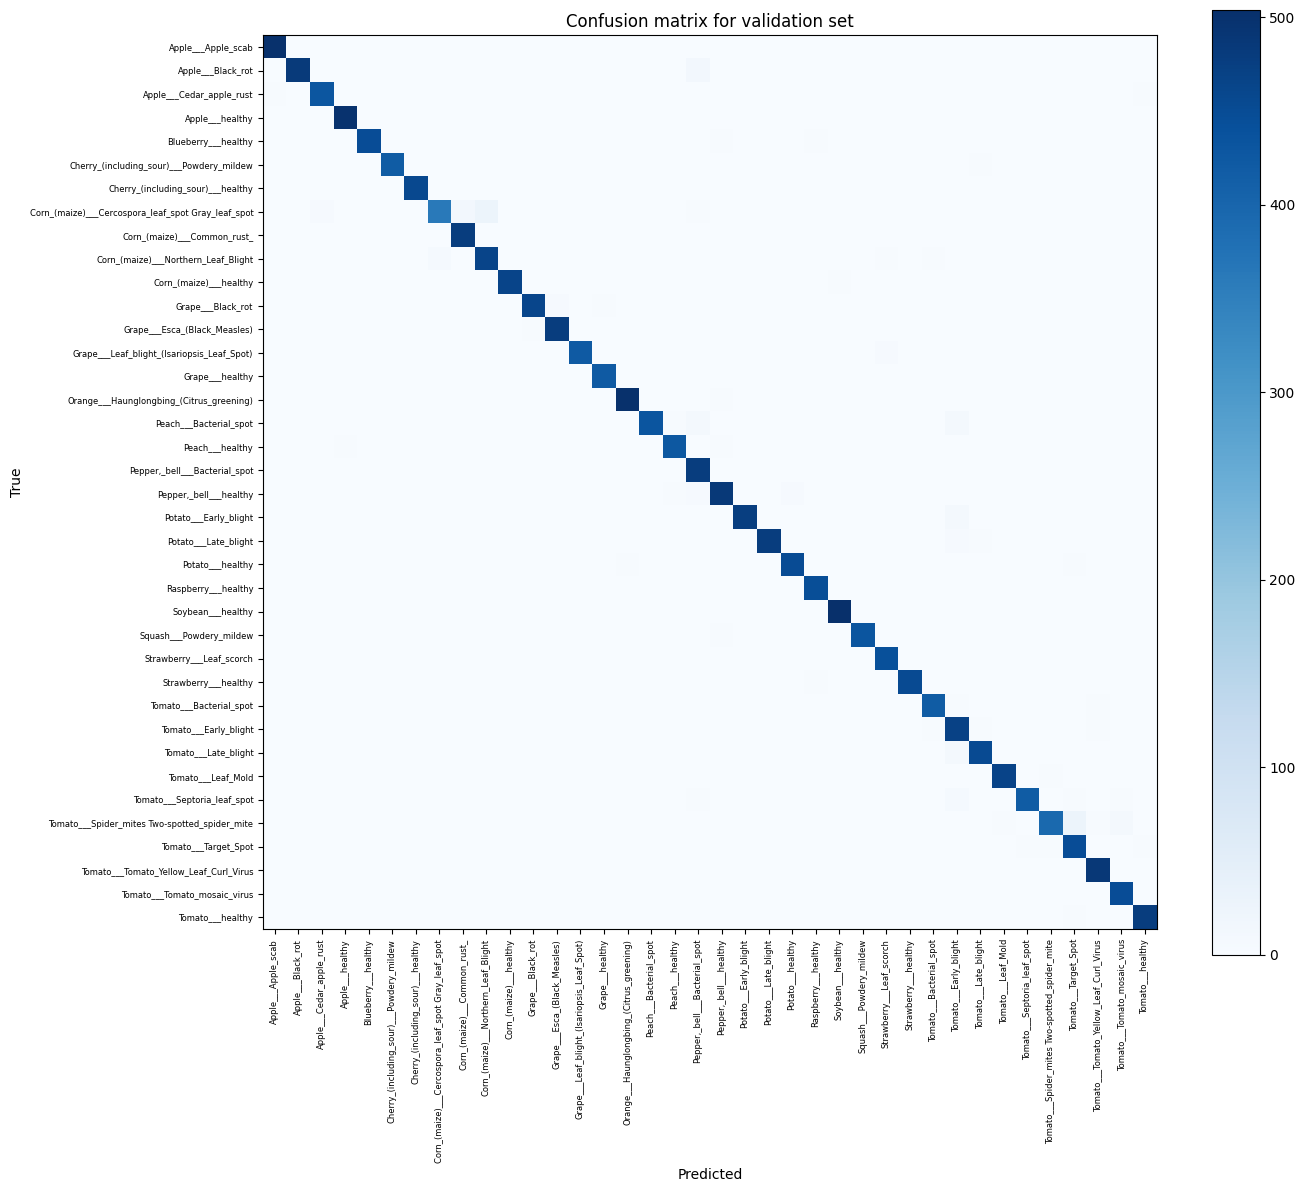

In [25]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90,
    fontsize=6
)
plt.yticks(
    range(len(class_names)),
    class_names,
    fontsize=6
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix for validation set")
plt.tight_layout()
plt.show()

In [26]:
errors = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            errors.append((cm[i, j], class_names[i], class_names[j]))

errors.sort(reverse=True)
print("Most frequent confusions (count, true, predicted):\n")
for count, true_c, pred_c, in errors[:10]:
    print(f"{count:4d}  {true_c}  ->  {pred_c}")

Most frequent confusions (count, true, predicted):

  27  Tomato___Spider_mites Two-spotted_spider_mite  ->  Tomato___Target_Spot
  27  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  ->  Corn_(maize)___Northern_Leaf_Blight
  13  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  ->  Corn_(maize)___Common_rust_
  12  Apple___Black_rot  ->  Pepper,_bell___Bacterial_spot
  11  Peach___Bacterial_spot  ->  Pepper,_bell___Bacterial_spot
   9  Tomato___Late_blight  ->  Tomato___Early_blight
   8  Tomato___Spider_mites Two-spotted_spider_mite  ->  Tomato___Tomato_mosaic_virus
   8  Potato___Early_blight  ->  Tomato___Early_blight
   8  Peach___Bacterial_spot  ->  Tomato___Early_blight
   7  Tomato___Septoria_leaf_spot  ->  Tomato___Early_blight
